# CAP4453 Robot Vision: Softmax Classifier

This notebook contains the implementation of a Softmax Classifier for CIFAR 10 or MNIST by Xavier Soto baron.


In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Choose device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Select dataset: 'cifar10' or 'mnist'
dataset_name = 'cifar10'

if dataset_name.lower() == 'cifar10':
    transform = transforms.Compose([transforms.ToTensor()])
    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    num_classes = 10
    input_dim = 32*32*3
elif dataset_name.lower() == 'mnist':
    transform = transforms.Compose([transforms.ToTensor()])
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    num_classes = 10
    input_dim = 28*28
else:
    raise ValueError('Unknown dataset')

# Split train into train/val
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")


Using device: cpu


100%|██████████| 170M/170M [17:36<00:00, 161kB/s]


Train samples: 45000, Validation samples: 5000, Test samples: 10000


In [2]:

import torch.nn as nn
import time # Import time module

class LinearClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        return self.fc(x)


# Initialize model, loss function and optimizer
model = LinearClassifier(input_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
weight_decay = 1e-4
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

#Initialize to Save Loss and accuracy per epoch
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []


# Training loop skeleton
num_epochs = 10
start_time = time.time() # Initialize start_time
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss = running_loss / total
    train_acc = 100. * correct / total
    #Added to save history loss and history accuracy
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # Evaluate on validation set
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Validation loss
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            # Validation accuracy
            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = 100. * val_correct / val_total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    print(f"Epoch {epoch+1}/{num_epochs}, Train loss: {train_loss:.4f}, Train acc: {train_acc:.2f}%, Val acc: {val_acc:.2f}%")

training_time = (time.time()- start_time)
best_val_acc = max(val_acc_history)
best_epoch = (np.argmax(val_acc_history)+ 1)

print()
print(f"Best validation accuracy: "f"{best_val_acc:.2f}%")
print(f"Best epoch: {best_epoch}")
print(f"Training time: "f"{training_time:.2f} seconds")

results = {
        "model": model,
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "training_time": training_time
  }


Epoch 1/10, Train loss: 2.2115, Train acc: 20.01%, Val acc: 25.80%
Epoch 2/10, Train loss: 2.0904, Train acc: 27.88%, Val acc: 29.00%
Epoch 3/10, Train loss: 2.0301, Train acc: 30.57%, Val acc: 31.66%
Epoch 4/10, Train loss: 1.9916, Train acc: 32.03%, Val acc: 32.46%
Epoch 5/10, Train loss: 1.9642, Train acc: 32.96%, Val acc: 32.56%
Epoch 6/10, Train loss: 1.9433, Train acc: 33.64%, Val acc: 33.70%
Epoch 7/10, Train loss: 1.9264, Train acc: 34.16%, Val acc: 33.92%
Epoch 8/10, Train loss: 1.9124, Train acc: 34.62%, Val acc: 34.26%
Epoch 9/10, Train loss: 1.9009, Train acc: 34.97%, Val acc: 34.44%
Epoch 10/10, Train loss: 1.8908, Train acc: 35.44%, Val acc: 35.16%

Best validation accuracy: 35.16%
Best epoch: 10
Training time: 82.00 seconds


In [7]:
def train_linear_model(input_dim, num_classes, train_dataset, val_dataset, device, learning_rate, weight_decay, batch_size, num_epochs):
    # Initialize model, loss function and optimizer
    model = LinearClassifier(input_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Initialize to Save Loss and accuracy per epoch
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    # Data loaders for this experiment
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    start_time = time.time()
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        train_loss = running_loss / total
        train_acc = 100. * correct / total
        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_running_loss / val_total
        val_acc = 100. * val_correct / val_total
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}, Train loss: {train_loss:.4f}, Train acc: {train_acc:.2f}%, Val acc: {val_acc:.2f}%")

    training_time = (time.time() - start_time)
    best_val_acc = max(val_acc_history)
    best_epoch = (np.argmax(val_acc_history) + 1)

    print()
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Best epoch: {best_epoch}")
    print(f"Training time: {training_time:.2f} seconds")

    results = {
        "model": model,
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "training_time": training_time
    }
    return results

In [ ]:
#Plot linear model accuracy
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_acc_history,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_acc_history,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Linear Classifier Graph: Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()


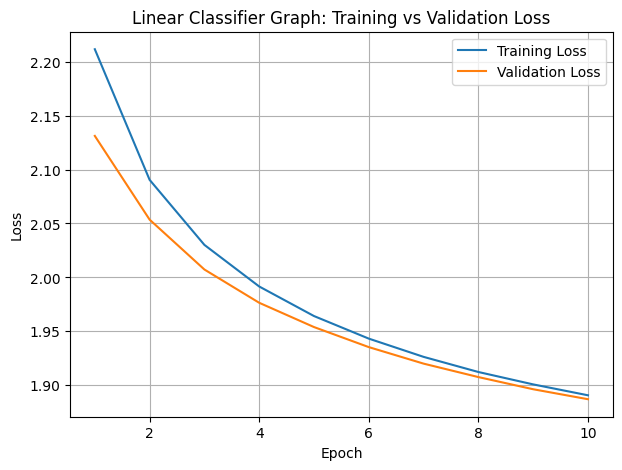

In [4]:
#Plot Loss
plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_loss_history,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss_history,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Linear Classifier Graph: Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [8]:
#Experiment testing with hyperparameters
experiments = [
    {
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 128,
        "num_epochs": 10
    },

    {
        "learning_rate": 1e-2,
        "weight_decay": 1e-4,
        "batch_size": 128,
        "num_epochs": 10
    },

    {
        "learning_rate": 1e-2,
        "weight_decay": 1e-3,
        "batch_size": 128,
        "num_epochs": 10
    },

    {
        "learning_rate": 1e-2,
        "weight_decay": 1e-4,
        "batch_size": 64,
        "num_epochs": 10
    }
]

#Initialize array for experiment results
experiment_results = []


for i, config in enumerate(experiments):

    print()
    print("=" * 70)
    print(f"EXPERIMENT {i + 1}")
    print("=" * 70)

    print(
        f"Learning rate: "
        f"{config['learning_rate']}"
    )

    print(
        f"Weight decay: "
        f"{config['weight_decay']}"
    )

    print(
        f"Batch size: "
        f"{config['batch_size']}"
    )

    print(
        f"Epochs: "
        f"{config['num_epochs']}"
    )

    print()


    result = train_linear_model(
        input_dim=input_dim,
        num_classes=num_classes,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        device=device,
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"],
        batch_size=config["batch_size"],
        num_epochs=config["num_epochs"]
    )


    experiment_results.append({
        **config,

        "best_val_acc":
            result["best_val_acc"],

        "best_epoch":
            result["best_epoch"],

        "result":
            result
    })


#Print out results
print()
print("LINEAR CLASSIFIER RESULTS")

print("-" * 85)

print(
    f"{'Run':<6}"
    f"{'LR':<12}"
    f"{'Weight Decay':<16}"
    f"{'Batch':<10}"
    f"{'Epochs':<10}"
    f"{'Best Val Acc':<15}"
)

print("-" * 85)

#Print Results
for i, result in enumerate(
    experiment_results
):

    print(
        f"{i+1:<6}"
        f"{result['learning_rate']:<12}"
        f"{result['weight_decay']:<16}"
        f"{result['batch_size']:<10}"
        f"{result['num_epochs']:<10}"
        f"{result['best_val_acc']:.2f}%"
    )


EXPERIMENT 1
Learning rate: 0.001
Weight decay: 0.0001
Batch size: 128
Epochs: 10

Epoch 1/10, Train loss: 2.1996, Train acc: 21.69%, Val acc: 27.76%
Epoch 2/10, Train loss: 2.0842, Train acc: 28.28%, Val acc: 30.00%
Epoch 3/10, Train loss: 2.0263, Train acc: 30.55%, Val acc: 31.86%
Epoch 4/10, Train loss: 1.9890, Train acc: 31.99%, Val acc: 32.82%
Epoch 5/10, Train loss: 1.9621, Train acc: 32.85%, Val acc: 32.86%
Epoch 6/10, Train loss: 1.9415, Train acc: 33.68%, Val acc: 33.18%
Epoch 7/10, Train loss: 1.9249, Train acc: 34.33%, Val acc: 33.48%
Epoch 8/10, Train loss: 1.9111, Train acc: 34.71%, Val acc: 34.22%
Epoch 9/10, Train loss: 1.8993, Train acc: 35.08%, Val acc: 35.02%
Epoch 10/10, Train loss: 1.8894, Train acc: 35.32%, Val acc: 35.24%

Best validation accuracy: 35.24%
Best epoch: 10
Training time: 85.19 seconds

EXPERIMENT 2
Learning rate: 0.01
Weight decay: 0.0001
Batch size: 128
Epochs: 10

Epoch 1/10, Train loss: 2.0052, Train acc: 28.80%, Val acc: 31.76%
Epoch 2/10, Train

In [9]:
best_experiment = max(
    experiment_results,
    key=lambda x: x["best_val_acc"]
)


print()
print("BEST LINEAR CONFIGURATION")

print(
    "Learning rate:",
    best_experiment["learning_rate"]
)

print(
    "Weight decay:",
    best_experiment["weight_decay"]
)

print(
    "Batch size:",
    best_experiment["batch_size"]
)

print(
    "Epochs:",
    best_experiment["num_epochs"]
)

print(
    "Best validation accuracy:",
    f"{best_experiment['best_val_acc']:.2f}%"
)

best_learning_rate = (
    best_experiment[
        "learning_rate"
    ]
)

best_weight_decay = (
    best_experiment[
        "weight_decay"
    ]
)

best_batch_size = (
    best_experiment[
        "batch_size"
    ]
)

best_num_epochs = (
    best_experiment[
        "num_epochs"
    ]
)


BEST LINEAR CONFIGURATION
Learning rate: 0.01
Weight decay: 0.001
Batch size: 128
Epochs: 10
Best validation accuracy: 39.36%


In [13]:
from torch.utils.data import ConcatDataset

combined_dataset = ConcatDataset([
    train_dataset,
    val_dataset
])


combined_loader = DataLoader(
    combined_dataset,
    batch_size=best_batch_size,
    shuffle=True,
    num_workers=2
)


test_loader = DataLoader(
    test_dataset,
    batch_size=best_batch_size,
    shuffle=False,
    num_workers=2
)


print(
    "Combined training samples:",
    len(combined_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)

Combined training samples: 50000
Test samples: 10000


In [15]:
SEED = 42

Final training Epoch 1/10 | Loss: 2.0001 | Accuracy: 29.19%
Final training Epoch 2/10 | Loss: 1.8690 | Accuracy: 34.92%
Final training Epoch 3/10 | Loss: 1.8303 | Accuracy: 36.42%
Final training Epoch 4/10 | Loss: 1.8106 | Accuracy: 37.12%
Final training Epoch 5/10 | Loss: 1.7947 | Accuracy: 37.92%
Final training Epoch 6/10 | Loss: 1.7840 | Accuracy: 38.28%
Final training Epoch 7/10 | Loss: 1.7753 | Accuracy: 38.53%
Final training Epoch 8/10 | Loss: 1.7669 | Accuracy: 39.12%
Final training Epoch 9/10 | Loss: 1.7616 | Accuracy: 39.16%
Final training Epoch 10/10 | Loss: 1.7552 | Accuracy: 39.62%

Final Test Loss: 1.7790
Final Test Accuracy: 38.58%


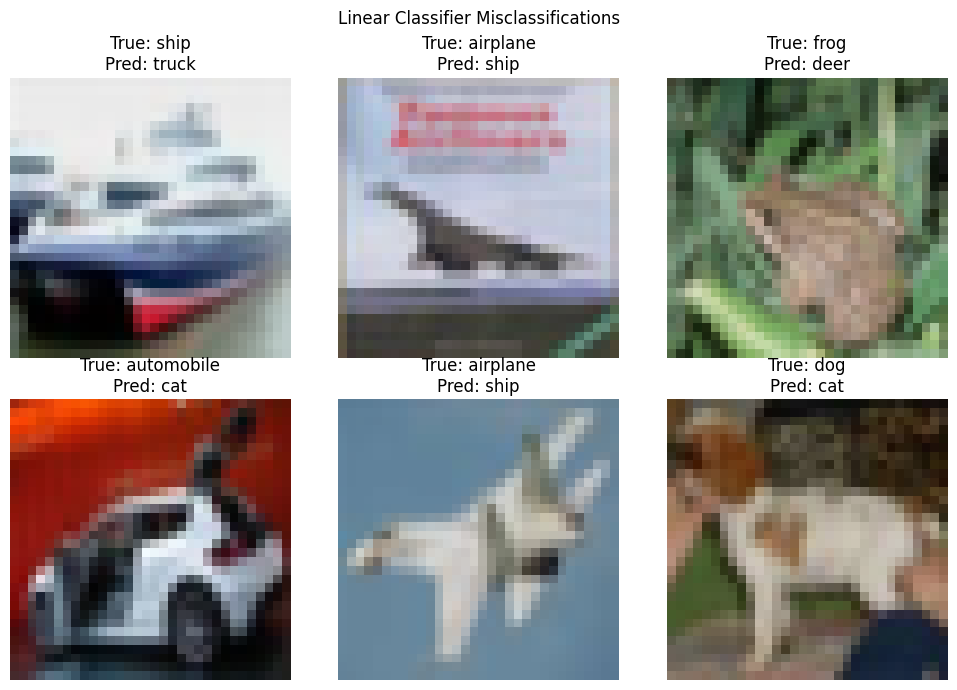

In [16]:
torch.manual_seed(SEED)


final_model = LinearClassifier(
    input_dim,
    num_classes
).to(device)


criterion = nn.CrossEntropyLoss()


final_optimizer = torch.optim.SGD(
    final_model.parameters(),
    lr=best_learning_rate,
    weight_decay=best_weight_decay
)

final_train_loss = []
final_train_acc = []


for epoch in range(best_num_epochs):

    final_model.train()

    running_loss = 0.0

    correct = 0
    total = 0


    for images, labels in combined_loader:

        images = images.to(device)
        labels = labels.to(device)


        final_optimizer.zero_grad()


        outputs = final_model(images)


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()


        final_optimizer.step()


        running_loss += (
            loss.item()
            * images.size(0)
        )


        _, predicted = outputs.max(1)


        total += labels.size(0)

        correct += (
            predicted.eq(labels)
            .sum()
            .item()
        )


    epoch_loss = (
        running_loss / total
    )


    epoch_acc = (
        100.0
        * correct
        / total
    )


    final_train_loss.append(
        epoch_loss
    )

    final_train_acc.append(
        epoch_acc
    )


    print(
        f"Final training "
        f"Epoch {epoch+1}/{best_num_epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_acc:.2f}%"
    )

    final_model.eval()


test_running_loss = 0.0

test_correct = 0
test_total = 0


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)


        outputs = final_model(images)


        loss = criterion(
            outputs,
            labels
        )


        test_running_loss += (
            loss.item()
            * images.size(0)
        )


        _, predicted = outputs.max(1)


        test_total += labels.size(0)

        test_correct += (
            predicted.eq(labels)
            .sum()
            .item()
        )


test_loss = (
    test_running_loss
    / test_total
)


test_accuracy = (
    100.0
    * test_correct
    / test_total
)


print()
print("=" * 50)

print(
    f"Final Test Loss: "
    f"{test_loss:.4f}"
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy:.2f}%"
)

print("=" * 50)

#MISCLASSIFICATION CLASSES:

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


misclassified_images = []
misclassified_true = []
misclassified_pred = []


final_model.eval()


with torch.no_grad():

    for images, labels in test_loader:

        images_device = images.to(device)

        labels_device = labels.to(device)


        outputs = final_model(
            images_device
        )


        _, predicted = outputs.max(1)


        for i in range(
            images.size(0)
        ):

            if (
                predicted[i]
                != labels_device[i]
            ):

                misclassified_images.append(
                    images[i]
                )

                misclassified_true.append(
                    labels[i].item()
                )

                misclassified_pred.append(
                    predicted[i].item()
                )


            if (
                len(misclassified_images)
                >= 6
            ):
                break


        if (
            len(misclassified_images)
            >= 6
        ):
            break

fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 7)
)


for i, ax in enumerate(
    axes.flat
):

    image = (
        misclassified_images[i]
        .permute(1, 2, 0)
    )


    ax.imshow(image)


    true_name = classes[
        misclassified_true[i]
    ]

    predicted_name = classes[
        misclassified_pred[i]
    ]


    ax.set_title(
        f"True: {true_name}\n"
        f"Pred: {predicted_name}"
    )


    ax.axis("off")


plt.suptitle(
    "Linear Classifier Misclassifications"
)

plt.tight_layout()

plt.show()